##  Imports

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import random


## Part 1 Geometric distribution

In [2]:
def geometric(amount, p=0.4):
    data = np.random.uniform(0,1,amount)
    res = []
    for num in data:
        res.append( np.floor(np.log(num)/(np.log((1-p))))  +1)
    return res

### Generate data

In [3]:
data_size = 10000
geometric_data = geometric(data_size, p = 0.4)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


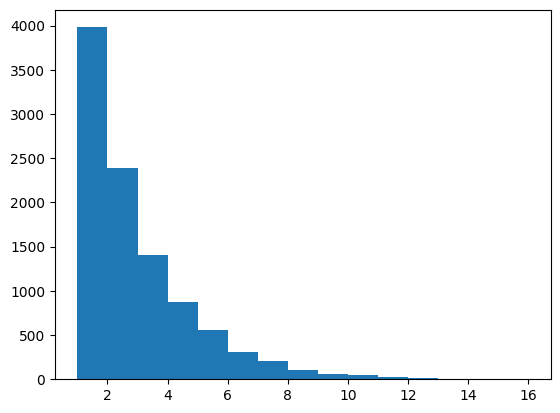

In [4]:

n = int(max(geometric_data))

bin_array = [x for x in range(1,n)]
print(bin_array)


(amounts,buckets,_) = plt.hist(geometric_data,bins =bin_array )

#truncate the amount array
truncated_amounts =[]
for amount in amounts:
    if amount > 5:
        truncated_amounts.append(amount)
    else:
        break
truncated_amounts.append(data_size - sum(truncated_amounts))

truncated_buckets = [buckets[i] for i in range(len(truncated_amounts)+1)]


plt.show()



In [59]:
def pdf(p, x):
    return (1-p)**(x-1) * p

T: 16.45879969059232
chi2:  0.42142404272027556


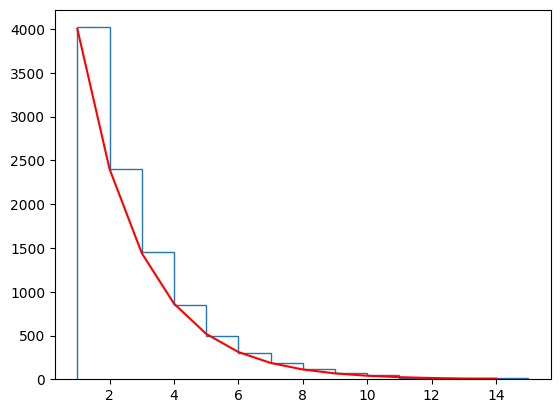

In [ ]:
pdf_data = [pdf(0.4,x) * data_size for x in range(1,int(n))]



truncated_pdf = [pdf_data[i] for i in range(0,len(truncated_amounts))]
truncated_pdf[-1] = (data_size - sum(truncated_pdf))


T = 0
for i in range(len(truncated_pdf)):
    T += (truncated_amounts[i] - truncated_pdf[i])**2 / truncated_pdf[i]

print("T:", T)

df = len(truncated_pdf) - 1
chi2 = 1 - stats.chi2.cdf(T, df=df)
print("df:", df)
print("chi2:", chi2)


x = [i for i in range(1, len(truncated_pdf)+1) ]
plt.plot(x,truncated_pdf ,color='red')

plt.stairs(truncated_amounts,truncated_buckets)
plt.show()


## Part 2

>### six-point distribution 

> ### setup

In [5]:
input_list = [7/48, 5/48, 1/8,1/16,1/4,5/16]

In [6]:

def crude(n, p_list):
    U = np.random.uniform(0,1,n)
    length = len(p_list)
    p_tot = 0
    result_array = []

    for Ui in U:
        p_tot = 0
        res = 1
        #print("Ui", Ui)
        for i in range(length):
           
            p_tot += p_list[i]
            #print("p_tot:", p_tot)
            if Ui < p_tot:
                result_array.append(res)
                break
            else:
                res +=1
            

    return result_array


[2, 1, 6, 6, 1, 1, 3, 1, 5, 3, 6, 2, 6, 3, 6, 6, 5, 2, 5, 4, 2, 3, 6, 6, 3, 6, 3, 1, 6, 3, 6, 6, 3, 6, 3, 6, 5, 6, 1, 5, 2, 1, 3, 6, 4, 6, 6, 2, 5, 6, 5, 1, 6, 6, 2, 3, 1, 6, 5, 5, 3, 4, 1, 1, 6, 1, 6, 6, 6, 1, 5, 5, 3, 6, 3, 5, 6, 1, 3, 5, 1, 1, 6, 5, 1, 5, 2, 5, 4, 1, 5, 6, 6, 4, 6, 2, 6, 6, 4, 5, 6, 6, 5, 6, 5, 5, 5, 6, 1, 1, 3, 6, 3, 3, 6, 2, 6, 6, 6, 2, 2, 6, 6, 1, 5, 3, 2, 3, 5, 3, 2, 6, 2, 2, 6, 5, 6, 1, 6, 6, 4, 1, 3, 5, 3, 3, 6, 1, 6, 2, 3, 1, 5, 5, 5, 5, 3, 2, 5, 5, 4, 6, 6, 2, 6, 6, 6, 1, 1, 3, 1, 1, 4, 5, 6, 6, 2, 5, 6, 1, 2, 6, 6, 3, 2, 4, 6, 6, 6, 6, 1, 5, 6, 3, 3, 6, 5, 1, 5, 2, 5, 2, 6, 5, 4, 5, 5, 1, 5, 6, 1, 6, 6, 5, 5, 2, 5, 5, 1, 6, 2, 5, 5, 4, 6, 3, 1, 6, 6, 5, 5, 1, 2, 6, 1, 2, 5, 6, 6, 3, 6, 1, 3, 6, 5, 5, 5, 1, 6, 2, 6, 6, 6, 5, 5, 3, 6, 6, 1, 1, 5, 6, 5, 3, 6, 3, 5, 2, 5, 6, 1, 3, 2, 6, 6, 1, 5, 6, 2, 2, 2, 5, 1, 6, 5, 1, 1, 5, 3, 6, 6, 6, 1, 5, 3, 6, 3, 1, 2, 3, 6, 6, 6, 5, 2, 6, 6, 6, 6, 6, 5, 6, 4, 5, 5, 6, 5, 2, 6, 2, 5, 5, 1, 3, 3, 3, 6, 6, 2, 5, 6, 2, 6, 

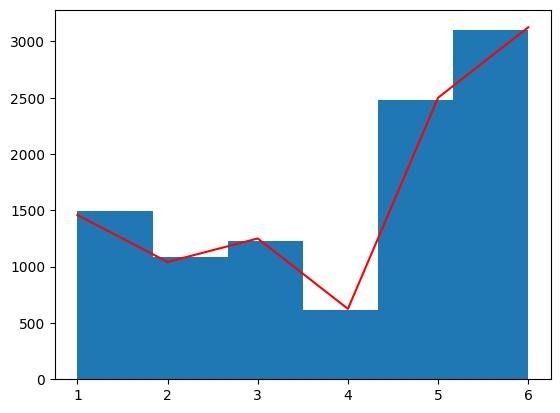

T: 3.571931428571415
chi2 test: 0.6125325317058424


In [7]:
crude_data = crude (data_size, input_list)

print(crude_data)
(crude_amount,crude_buckets,_) = plt.hist(crude_data, bins=6)

teori =  [p * data_size for p in input_list]
print(teori)
x = [i for i in range(1,len(input_list) + 1)]
plt.plot(x, teori, color = "red")

plt.show()

T = 0
for i in range(0, len(input_list)):
    T += (crude_amount[i] - teori[i])**2 / teori[i]

print("T:", T)

crude_df = len(input_list) - 1
print("chi2 test:", stats.chi2.sf(T, crude_df))

>### Rejection method

In [8]:
def rejection(n, p_list):
    c = 0.0000001 + max(p_list)
    result_array = []

    while len(result_array) < n:
        I = int(np.random.uniform(1, len(p_list) + 1))
        U = np.random.uniform(0, 1)

        if U <= p_list[I - 1] / c:
            result_array.append(I)

    return result_array

[5, 6, 1, 3, 3, 6, 3, 1, 1, 6, 3, 6, 6, 5, 3, 5, 5, 2, 5, 6, 3, 6, 3, 1, 3, 5, 1, 1, 1, 5, 6, 2, 6, 1, 6, 6, 5, 5, 3, 5, 6, 5, 4, 6, 3, 6, 6, 1, 6, 6, 1, 6, 6, 3, 6, 5, 5, 5, 6, 6, 5, 5, 3, 1, 5, 5, 6, 1, 5, 6, 5, 6, 2, 6, 4, 2, 4, 6, 6, 5, 1, 2, 4, 6, 6, 6, 5, 6, 2, 6, 5, 2, 5, 4, 6, 5, 2, 4, 1, 3, 1, 5, 2, 2, 5, 5, 1, 6, 3, 5, 5, 4, 4, 2, 4, 6, 2, 1, 4, 6, 1, 5, 2, 3, 5, 2, 6, 6, 6, 5, 2, 6, 3, 3, 6, 6, 6, 4, 1, 1, 5, 5, 1, 3, 6, 6, 6, 6, 6, 1, 1, 6, 5, 5, 1, 3, 6, 5, 6, 6, 6, 6, 5, 1, 6, 3, 5, 6, 6, 2, 3, 5, 6, 2, 6, 6, 2, 2, 1, 4, 2, 1, 6, 5, 6, 2, 6, 3, 6, 5, 6, 6, 6, 6, 2, 3, 6, 6, 6, 6, 2, 1, 6, 3, 6, 5, 5, 3, 5, 5, 5, 1, 5, 2, 5, 2, 4, 4, 4, 1, 6, 6, 1, 3, 5, 6, 1, 5, 6, 3, 5, 6, 6, 3, 5, 5, 6, 6, 6, 5, 5, 6, 5, 5, 5, 5, 6, 6, 3, 5, 1, 6, 3, 5, 1, 5, 5, 5, 6, 3, 5, 5, 1, 1, 6, 5, 6, 6, 4, 3, 5, 6, 6, 5, 5, 2, 1, 2, 5, 6, 1, 6, 5, 4, 5, 6, 6, 6, 3, 1, 1, 1, 6, 6, 6, 1, 6, 6, 3, 3, 5, 6, 4, 2, 6, 5, 2, 1, 5, 1, 6, 3, 6, 5, 3, 2, 5, 1, 6, 6, 2, 5, 6, 4, 6, 4, 2, 5, 6, 4, 4, 4, 1, 

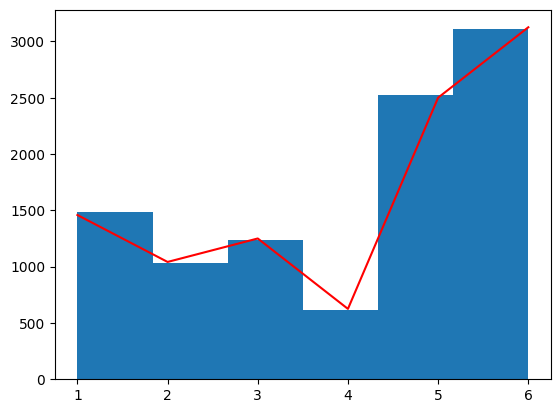

1.4060914285714243
rejection chi2 test: 0.9236457779821852


In [11]:
rejection_data = rejection (data_size, input_list)

print(rejection_data)
(rejection_amount,rejection_buckets,_) = plt.hist(rejection_data, bins=6)

rejection_teori =  [p * data_size for p in input_list]
print("rejection teori:",rejection_teori)

x = [i for i in range(1,len(input_list) + 1)]
plt.plot(x, rejection_teori, color = "red")

plt.show()

T = 0
for i in range(0, len(input_list)):
    T += (rejection_amount[i] - rejection_teori[i])**2 / rejection_teori[i]
print(T)
rejection_df = len(input_list)-1
print("rejection chi2 test:", stats.chi2.sf(T, rejection_df))

### Alias

In [12]:
def alias(n,p_list):
    result_array = []


    L = [i for i in range(len(p_list))]

    F = [len(p_list) * p for p in p_list]
    G = []
    S = []
    for i in range(len(F)):
        if F[i] >= 1:
            G.append(i)
        else:
            S.append(i)
    
    print('S',S)

    while(len(S) != 0):
        i = G[0]
        j = S[0]
        L[j] = i
        print(j,i)
        F[i] = F[i]-(1-F[j])
        if F[i] < 1:
            G.pop(0)
            S.append(i)
        S.pop(0)
    # print(f'L:{L} \n F:{F}')

    for i in range(n):
        I = int(np.random.uniform(low=0,high = len(p_list)))
        #print('I',I)
        U = np.random.uniform(0,1)
        if U <= F[I]:
            result_array.append(I+1)
        else:
            result_array.append(L[I] + 1)
            
    return result_array



S [0, 1, 2, 3]
0 4
1 4
2 4
3 5
4 5
[1, 6, 6, 5, 5, 3, 6, 1, 5, 6, 5, 6, 2, 5, 6, 5, 6, 6, 3, 1, 3, 6, 5, 1, 1, 5, 1, 5, 5, 6, 6, 5, 5, 1, 6, 4, 4, 6, 5, 6, 6, 3, 6, 3, 6, 1, 5, 3, 3, 6, 1, 3, 2, 5, 5, 3, 6, 1, 6, 1, 5, 1, 1, 6, 5, 1, 5, 3, 5, 5, 6, 3, 5, 5, 1, 6, 1, 5, 6, 5, 6, 6, 6, 3, 2, 6, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 6, 6, 4, 5, 4, 2, 5, 6, 5, 5, 3, 6, 2, 3, 6, 1, 5, 3, 5, 5, 6, 5, 4, 6, 1, 4, 5, 6, 6, 1, 1, 5, 3, 5, 2, 2, 4, 6, 4, 4, 2, 6, 1, 5, 6, 5, 6, 5, 6, 3, 1, 6, 5, 3, 5, 5, 5, 1, 2, 2, 4, 5, 6, 4, 3, 4, 6, 1, 3, 3, 1, 6, 1, 6, 6, 1, 5, 1, 6, 3, 2, 1, 3, 6, 3, 5, 2, 6, 4, 6, 2, 5, 1, 5, 3, 3, 5, 6, 5, 6, 1, 5, 5, 3, 6, 4, 6, 6, 4, 5, 5, 4, 2, 2, 4, 5, 3, 1, 3, 5, 5, 5, 1, 5, 5, 2, 1, 4, 2, 3, 6, 1, 5, 5, 6, 3, 1, 6, 6, 5, 5, 5, 2, 6, 6, 1, 6, 4, 6, 4, 5, 3, 6, 4, 5, 1, 5, 6, 4, 5, 4, 6, 2, 1, 2, 4, 6, 1, 5, 5, 6, 1, 5, 5, 4, 5, 1, 1, 6, 3, 6, 4, 6, 6, 5, 5, 2, 6, 5, 4, 1, 1, 1, 5, 3, 6, 4, 6, 5, 2, 1, 6, 3, 5, 6, 6, 3, 5, 1, 1, 2, 3, 5, 6, 5, 1, 3, 2, 1, 5, 6, 1, 5, 2, 5, 1

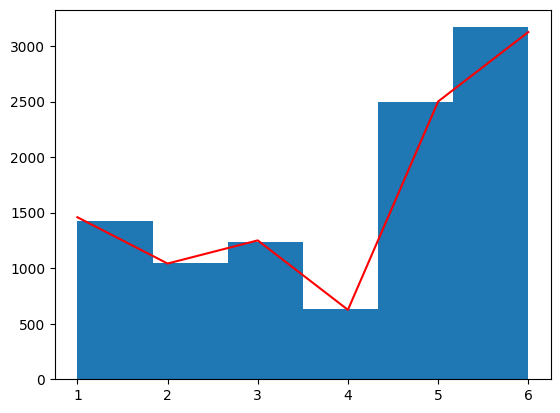

1.44412571428572
alias chi2 test: 0.9194262267130989
[1429. 1044. 1235.  631. 2493. 3168.]


In [14]:
alias_data = alias (data_size, input_list)

print(alias_data)
(alias_amount,alias_buckets,_) = plt.hist(alias_data, bins=6)

alias_teori =  [p * data_size for p in input_list]
print("alias teori:",alias_teori)

x = [i for i in range(1,len(input_list) + 1)]
plt.plot(x, alias_teori, color = "red")

plt.show()

T = 0
for i in range(0, len(input_list)):
    T += (alias_amount[i] - alias_teori[i])**2 / alias_teori[i]
print(T)
alias_df = len(input_list)-1
print("alias chi2 test:", stats.chi2.sf(T, alias_df))
print(alias_amount)

## Part 3

### Comparing time

In [15]:
import time

def time_method(method, n, p_list):
    start = time.time()
    data = method(n, p_list)
    end = time.time()
    return end - start, data

In [16]:
n = 100000

crude_time, crude_data = time_method(crude, n, input_list)
rejection_time, rejection_data = time_method(rejection, n, input_list)
alias_time, alias_data = time_method(alias, n, input_list)

print("Crude method time:", crude_time)
print("Rejection method time:", rejection_time)
print("Alias method time:", alias_time)

S [0, 1, 2, 3]
0 4
1 4
2 4
3 5
4 5
Crude method time: 0.027055740356445312
Rejection method time: 0.4981672763824463
Alias method time: 0.2607080936431885


### Accuracy test

In [17]:
def print_frequencies(data, p_list):
    counts = np.bincount(data, minlength=len(p_list)+1)[1:]
    frequencies = counts / len(data)

    print("Observed frequencies:", frequencies)
    print("Theoretical probabilities:", p_list)

In [18]:
print("Crude method")
print_frequencies(crude_data, input_list)

print("\nRejection method")
print_frequencies(rejection_data, input_list)

print("\nAlias method")
print_frequencies(alias_data, input_list)

Crude method
Observed frequencies: [0.14398 0.10309 0.12568 0.06194 0.2513  0.31401]
Theoretical probabilities: [0.14583333333333334, 0.10416666666666667, 0.125, 0.0625, 0.25, 0.3125]

Rejection method
Observed frequencies: [0.1466  0.10444 0.12721 0.06101 0.24924 0.3115 ]
Theoretical probabilities: [0.14583333333333334, 0.10416666666666667, 0.125, 0.0625, 0.25, 0.3125]

Alias method
Observed frequencies: [0.14496 0.10298 0.12465 0.0636  0.24984 0.31397]
Theoretical probabilities: [0.14583333333333334, 0.10416666666666667, 0.125, 0.0625, 0.25, 0.3125]


## Part 4